In [1]:
import tskit, msprime, pyslim 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import IntervalIndex

In [2]:
ts = tskit.load('results/hh_full_ne_1000_s_0.1_replicate_0.tree')

In [3]:
ts

In [4]:
def tree_heights(ts):
    heights = np.zeros(ts.num_trees + 1)
    for tree in ts.trees():
        if tree.num_roots > 1: # not fully coalesced
            heights[tree.index] = ts.metadata['SLiM']['generations']
        else:
            children = tree.children(tree.root)
            real_root = tree.root if len(children) > 1 else children[0]
            heights[tree.index] = tree.time(real_root)
    heights[-1] = heights[-2] 
    return heights

In [5]:
# Recapitate with recombination map 
ends = pd.read_csv('ends_chr12_pyslim.csv', names=['ends'],index_col=False)
ends = ends['ends'].tolist()
rates = pd.read_csv('rates_chr12_pyslim.csv',names=['rates'],index_col=False)
rates = rates['rates'].tolist()

In [6]:
recomb_map = msprime.RateMap(position=ends, rate=rates)

In [7]:
recap = pyslim.recapitate(ts,
                recombination_rate=recomb_map,
                ancestral_Ne=1e3)

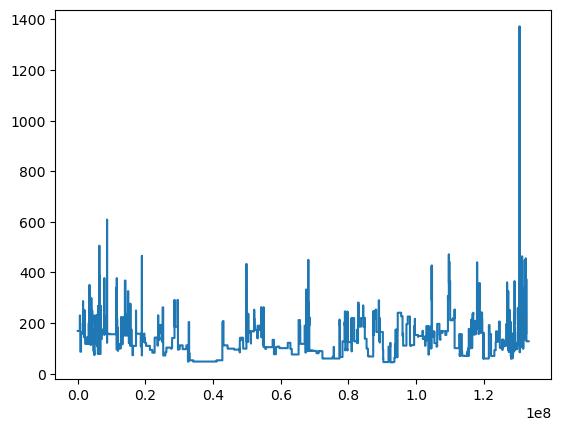

In [8]:
breakpoints = list(recap.breakpoints())
heights = tree_heights(recap)
plt.step(breakpoints, heights, where='post')
plt.show()

In [9]:
orig_max_roots = max(t.num_roots for t in ts.trees())
recap_max_roots = max(t.num_roots for t in recap.trees())
print(f"Maximum number of roots before recapitation: {orig_max_roots}\n"
      f"After recapitation: {recap_max_roots}")

Maximum number of roots before recapitation: 1
After recapitation: 1


In [14]:
print(f"The tree sequence started with {recap.num_mutations} mutations,\n"
      f"and mean pairwise nucleotide diversity is {recap.diversity():0.3e}.")

The tree sequence started with 687007 mutations,
and mean pairwise nucleotide diversity is 3.137e-06.


In [15]:
tree = recap.simplify()
next_id = pyslim.next_slim_mutation_id(tree)
mts = msprime.sim_mutations(
           tree,
           rate=1e-6,
           model=msprime.SLiMMutationModel(type=0, next_id=next_id),
           keep=True,
)

In [16]:
print(f"The tree sequence now has {mts.num_mutations} mutations,\n"
      f"and mean pairwise nucleotide diversity is {mts.diversity():0.3e}.")

The tree sequence now has 1628284 mutations,
and mean pairwise nucleotide diversity is 1.260e-04.


In [43]:
windows = np.linspace(0, mts.sequence_length, 1300)
pi = mts.diversity(mts.samples(), windows=windows)
taj_d = mts.Tajimas_D(mts.samples(), windows=windows)

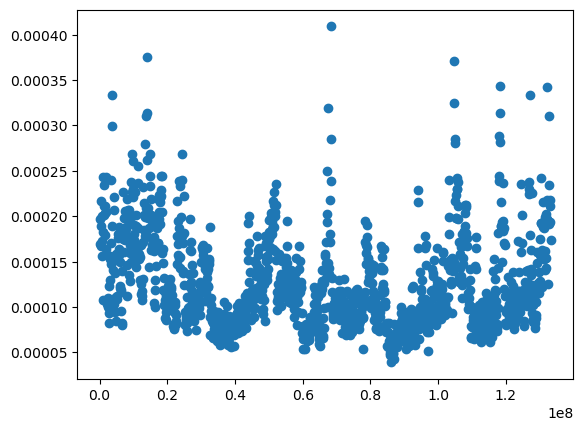

In [44]:
plt.scatter(windows[1:],pi)

In [90]:
windows = windows.astype(int)
df = pd.DataFrame({'left':(windows[:len(windows)-1]),'right':windows[1:],'pi':pi})
df['mid'] = df['left']+((df['right']-df['left']) // 2)
df['span'] = df['right']-df['left']

In [91]:
df

,left,right,pi,mid,span
0,0,102598,0.000169,51299,102598
1,102598,205196,0.000197,153897,102598
2,205196,307795,0.000168,256495,102599
3,307795,410393,0.000217,359094,102598
4,410393,512991,0.000189,461692,102598
...,...,...,...,...,...
1294,132762318,132864916,0.000191,132813617,102598
1295,132864916,132967514,0.000218,132916215,102598
1296,132967514,133070113,0.000194,133018813,102599
1297,133070113,133172711,0.000211,133121412,102598


In [92]:
rates_df = pd.DataFrame({
        'left': recomb_map.position[:-1].astype(int),  
        'right': recomb_map.position[1:].astype(int),     
        'rate': recomb_map.rate             
    })
rates_df['mid'] = rates_df['left']+((rates_df['right']-rates_df['left']) // 2)
rates_df['span'] = rates_df['right']-rates_df['left']
rates_df

,left,right,rate,mid,span
0,0,586911,0.000000e+00,293455,586911
1,586911,590277,5.271164e-09,588594,3366
2,590277,592350,2.261057e-19,591313,2073
3,592350,597766,1.477229e-11,595058,5416
4,597766,598043,4.679276e-10,597904,277
...,...,...,...,...,...
55158,132635995,132641264,1.145616e-11,132638629,5269
55159,132641264,132643244,5.190081e-12,132642254,1980
55160,132643244,132660159,0.000000e+00,132651701,16915
55161,132660159,132699697,0.000000e+00,132679928,39538


In [95]:

rate_intervals = IntervalIndex.from_arrays(rates_df['left'], rates_df['right'], closed='both')

result = df.copy()
weighted_rates = []

for idx, window in df.iterrows():
    window_left = window['left']
    window_right = window['right']
    # Find overlapping intervals
    overlap_mask = rate_intervals.overlaps(pd.Interval(window_left, window_right, closed='both'))
    overlapping_rates = rates_df[overlap_mask].copy()
    if len(overlapping_rates) == 0:
        weighted_rates.append(np.nan)
    else:
        # Calculate overlap lengths
        overlap_starts = np.maximum(overlapping_rates['left'].values, window_left)
        overlap_ends = np.minimum(overlapping_rates['right'].values, window_right)
        overlap_lengths = overlap_ends - overlap_starts
       # Calculate weighted mean
        weights = overlap_lengths / overlap_lengths.sum()
        weighted_rate = (overlapping_rates['rate'].values * weights).sum()
        weighted_rates.append(weighted_rate)

result['rate'] = weighted_rates

In [96]:
result

,left,right,pi,mid,span,rate
0,0,102598,0.000169,51299,102598,0.0
1,102598,205196,0.000197,153897,102598,0.0
2,205196,307795,0.000168,256495,102599,0.0
3,307795,410393,0.000217,359094,102598,0.0
4,410393,512991,0.000189,461692,102598,0.0
...,...,...,...,...,...,...
1294,132762318,132864916,0.000191,132813617,102598,0.0
1295,132864916,132967514,0.000218,132916215,102598,0.0
1296,132967514,133070113,0.000194,133018813,102599,0.0
1297,133070113,133172711,0.000211,133121412,102598,0.0


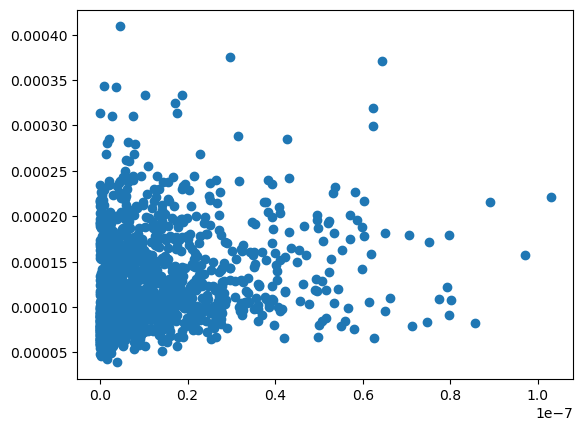

In [99]:
plt.scatter(result['rate'],result['pi'])

/home/bjarkemp/miniforge3/envs/recapitation/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


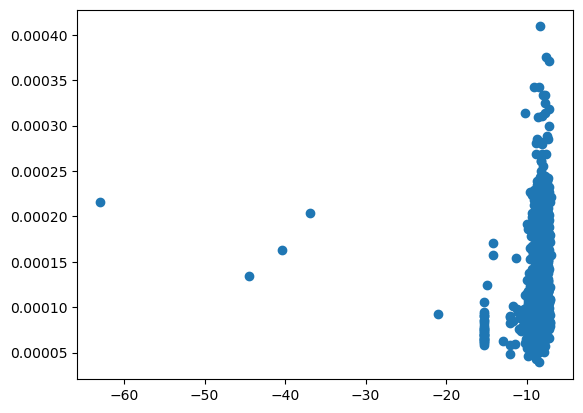

In [100]:
plt.scatter(np.log10(result['rate']),result['pi'])

In [102]:
result['bin'] = pd.cut(result['rate'], bins=20)

In [103]:
result

,left,right,pi,mid,span,rate,bin
0,0,102598,0.000169,51299,102598,0.0,"(-1.03e-10, 5.15e-09]"
1,102598,205196,0.000197,153897,102598,0.0,"(-1.03e-10, 5.15e-09]"
2,205196,307795,0.000168,256495,102599,0.0,"(-1.03e-10, 5.15e-09]"
3,307795,410393,0.000217,359094,102598,0.0,"(-1.03e-10, 5.15e-09]"
4,410393,512991,0.000189,461692,102598,0.0,"(-1.03e-10, 5.15e-09]"
...,...,...,...,...,...,...,...
1294,132762318,132864916,0.000191,132813617,102598,0.0,"(-1.03e-10, 5.15e-09]"
1295,132864916,132967514,0.000218,132916215,102598,0.0,"(-1.03e-10, 5.15e-09]"
1296,132967514,133070113,0.000194,133018813,102599,0.0,"(-1.03e-10, 5.15e-09]"
1297,133070113,133172711,0.000211,133121412,102598,0.0,"(-1.03e-10, 5.15e-09]"


In [107]:
test = result.groupby('bin').median()

/tmp/ipykernel_1268425/2244331591.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test = result.groupby('bin').median()


In [110]:
test

,left,right,pi,mid,span,rate
bin,,,,,,
"(-1.03e-10, 5.15e-09]",62072026.0,62174624.0,0.000100,62123325.0,102598.0,1.450913e-09
"(5.15e-09, 1.03e-08]",66945449.5,67048048.0,0.000115,66996748.5,102598.0,7.440334e-09
"(1.03e-08, 1.54e-08]",62790214.5,62892813.5,0.000118,62841513.5,102598.0,1.303748e-08
"(1.54e-08, 2.06e-08]",68381827.0,68484425.5,0.000120,68433126.0,102598.0,1.754882e-08
"(2.06e-08, 2.57e-08]",68946118.5,69048716.5,0.000119,68997417.5,102598.0,2.248511e-08
"(2.57e-08, 3.09e-08]",70690291.0,70792889.0,0.000121,70741590.0,102598.0,2.757676e-08
"(3.09e-08, 3.6e-08]",96237290.0,96339889.0,0.000128,96288589.0,102598.0,3.286544e-08
"(3.6e-08, 4.12e-08]",76128006.0,76230604.0,0.000125,76179305.0,102598.0,3.865419e-08
"(4.12e-08, 4.63e-08]",95826897.0,95929495.0,0.000153,95878196.0,102598.0,4.287633e-08


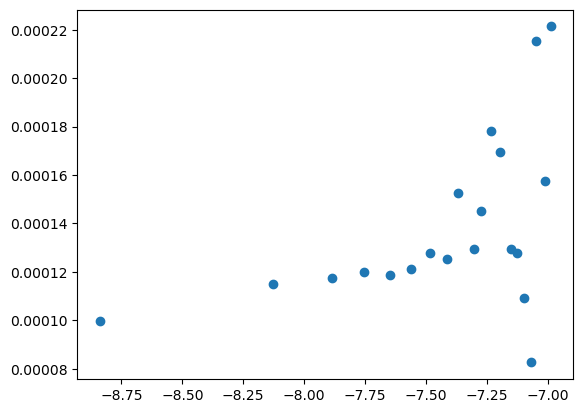

In [112]:
plt.scatter(np.log10(test['rate']),test['pi'])